# LogGuardian — Analyse des feedbacks négatifs par version du modèle

Ce notebook est adapté au fonctionnement actuel de LogGuardian :

- seuls les clics **👎 Pas utile** sont enregistrés ;
- chaque enregistrement contient le log, l'analyse RAG, la recommandation et la version du modèle ;
- le notebook sert à identifier les cas problématiques et à comparer les versions du modèle.

> **Limite importante :** un pouce négatif signifie que l'explication ou la recommandation n'a pas été jugée utile. Il ne constitue pas automatiquement une vérité terrain indiquant que la classification du modèle est fausse.  
> Avec uniquement les retours négatifs, on ne peut pas calculer correctement l'accuracy, la précision, le rappel ou le F1-score du modèle. Pour cela, il faut un feedback séparé du type « vraie anomalie / faux positif / vrai normal / anomalie manquée ».


## 1. Imports et détection des chemins du projet

In [30]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 180)
pd.set_option("display.max_columns", None)


def find_project_root(start: Path | None = None) -> Path:
    """Recherche la racine LogGuardian depuis le dossier courant."""
    start = (start or Path.cwd()).resolve()

    candidates = [start, *start.parents]

    for candidate in candidates:
        if (
            (candidate / "feedback").exists()
            and (candidate / "ml-model").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Racine LogGuardian introuvable. "
        "Lance le notebook depuis le projet ou adapte PROJECT_ROOT manuellement."
    )


PROJECT_ROOT = find_project_root()

FEEDBACK_PATH = PROJECT_ROOT / "feedback" / "rag_feedback.jsonl"

MODEL_META_CANDIDATES = [
    PROJECT_ROOT / "ml-model" / "models" / "threshold.json",
    PROJECT_ROOT / "models" / "threshold.json",
]

MODEL_META_PATH = next(
    (path for path in MODEL_META_CANDIDATES if path.exists()),
    None,
)

EXPORT_PATH = PROJECT_ROOT / "feedback" / "negative_feedback_analysis.csv"

print("PROJECT_ROOT   :", PROJECT_ROOT)
print("FEEDBACK_PATH  :", FEEDBACK_PATH)
print("MODEL_META_PATH:", MODEL_META_PATH)
print("EXPORT_PATH    :", EXPORT_PATH)


PROJECT_ROOT   : C:\Users\eyakh\Downloads\logguardian
FEEDBACK_PATH  : C:\Users\eyakh\Downloads\logguardian\feedback\rag_feedback.jsonl
MODEL_META_PATH: C:\Users\eyakh\Downloads\logguardian\ml-model\models\threshold.json
EXPORT_PATH    : C:\Users\eyakh\Downloads\logguardian\feedback\negative_feedback_analysis.csv


In [31]:
import sys

print(sys.executable)

c:\Users\eyakh\Downloads\logguardian\.venv\Scripts\python.exe


## 2. Chargement robuste du fichier JSONL

In [32]:
def load_jsonl(path: Path) -> tuple[list[dict], list[dict]]:
    records = []
    errors = []

    if not path.exists():
        raise FileNotFoundError(
            f"Fichier de feedback introuvable : {path}"
        )

    with path.open("r", encoding="utf-8") as file:
        for line_number, line in enumerate(file, start=1):
            line = line.strip()

            if not line:
                continue

            try:
                value = json.loads(line)

                if isinstance(value, dict):
                    records.append(value)
                else:
                    errors.append({
                        "line": line_number,
                        "error": "La ligne JSON n'est pas un objet.",
                    })

            except json.JSONDecodeError as error:
                errors.append({
                    "line": line_number,
                    "error": str(error),
                })

    return records, errors


raw_records, parsing_errors = load_jsonl(FEEDBACK_PATH)

print(f"Lignes JSON valides : {len(raw_records)}")
print(f"Lignes invalides     : {len(parsing_errors)}")

if parsing_errors:
    display(pd.DataFrame(parsing_errors))


Lignes JSON valides : 79
Lignes invalides     : 0


## 3. Normalisation et conservation des feedbacks négatifs

In [33]:
df_raw = pd.DataFrame(raw_records)

if df_raw.empty:
    raise ValueError("Le fichier JSONL ne contient aucun feedback.")

# Compatibilité avec les anciens et nouveaux noms de colonnes.
if "feedback_timestamp" in df_raw.columns:
    timestamp_series = df_raw["feedback_timestamp"]
else:
    timestamp_series = pd.Series(index=df_raw.index, dtype="object")

if "timestamp" in df_raw.columns:
    timestamp_series = timestamp_series.fillna(df_raw["timestamp"])

df_raw["timestamp_normalized"] = pd.to_datetime(
    timestamp_series,
    errors="coerce",
    utc=True,
)

df_raw["feedback"] = (
    df_raw.get("feedback", "")
    .astype(str)
    .str.strip()
    .str.lower()
)

df_raw["model_version"] = "unknown"

if "detection_model_version" in df_raw.columns:
    df_raw["model_version"] = (
        df_raw["detection_model_version"]
        .fillna("unknown")
        .astype(str)
    )

if "model_version" in df_raw.columns:
    # Cette colonne existe déjà après l'initialisation ci-dessus.
    original_model = pd.Series(
        [record.get("model_version") for record in raw_records],
        index=df_raw.index,
        dtype="object",
    )
    df_raw["model_version"] = (
        original_model
        .fillna(df_raw["model_version"])
        .fillna("unknown")
        .astype(str)
    )

df_raw["score_ia"] = pd.to_numeric(
    df_raw.get("score_ia"),
    errors="coerce",
)

df_raw["ratio_val"] = pd.to_numeric(
    df_raw.get("ratio", "")
    .astype(str)
    .str.replace("x", "", regex=False),
    errors="coerce",
)

df_raw["statut"] = (
    df_raw.get("statut", "UNKNOWN")
    .fillna("UNKNOWN")
    .astype(str)
    .str.upper()
)

df_raw["source"] = (
    df_raw.get("source", "unknown")
    .fillna("unknown")
    .astype(str)
)

df_raw["host"] = (
    df_raw.get("host", "unknown")
    .fillna("unknown")
    .astype(str)
)

df_raw["log_id"] = (
    df_raw.get("log_id", "")
    .fillna("")
    .astype(str)
)

# Le nouveau comportement de l'application enregistre uniquement les négatifs.
df_negative = df_raw[df_raw["feedback"] == "negative"].copy()

# Un même log peut être cliqué plusieurs fois : on garde le dernier retour négatif.
df_negative = (
    df_negative
    .sort_values("timestamp_normalized")
    .drop_duplicates(subset=["log_id"], keep="last")
    .sort_values("timestamp_normalized", ascending=False)
    .reset_index(drop=True)
)

print(f"Feedbacks bruts                  : {len(df_raw)}")
print(f"Feedbacks négatifs uniques       : {len(df_negative)}")
print(f"Versions du modèle représentées  : {df_negative['model_version'].nunique()}")

if df_negative.empty:
    print(
        "\nAucun feedback négatif disponible. "
        "Clique sur « Pas utile » dans l'interface pour créer un exemple."
    )

display(df_negative.head())


Feedbacks bruts                  : 79
Feedbacks négatifs uniques       : 8
Versions du modèle représentées  : 1


,feedback_timestamp,feedback,log_id,source,host,message,score_ia,ratio,statut,model_version,rag_analysis,rag_recommendation,rag_version,prompt_version,regeneration_prompt_version,alert_threshold,replacement_rag_analysis,replacement_rag_recommendation,replacement_generator,groq_success,groq_error,accepted,accepted_rag_analysis,accepted_rag_recommendation,timestamp_normalized,ratio_val
0,2026-06-15T21:47:01,negative,2026-06-15T16:23:02.546774+00:00_260542,linux,combo,session opened for user test by (uid=509),2.35,1.80x,ANOMALIE,lstm_v1_20260501,"Le message indique qu’une session a été ouverte pour l’utilisateur « test » avec l’UID 509 sur le hôte « combo ». Le score IA de 2,35 suggère une détection d’anomalie, et le ra...","1. Vérifier les logs d’authentification autour de ce timestamp pour confirmer qu’il s’agit d’une connexion légitime. 2. Si aucune activité suspecte n’est trouvée, ajuster le se...",rag_v1,prompt_v1,groq_regeneration_v1,1.3,"Le log signale l’ouverture d’une session pour l’utilisateur « test » (UID 509) sur l’hôte « combo ». Le score IA de 2,35 et le ratio de 1,80× dépassent le seuil de 1,3×, indiqu...","1. Examiner les logs d’authentification autour de ce timestamp pour confirmer la légitimité du login. 2. Si aucune activité suspecte n’est détectée, envisager d’ajuster légèrem...",openai/gpt-oss-20b,True,NaN,NaN,NaN,NaN,2026-06-15 21:47:01+00:00,1.80
1,2026-06-15T21:46:49,negative,2026-06-15T16:23:02.564857+00:00_343552,linux,combo,session opened for user test by (uid=509),2.02,1.55x,ANOMALIE,lstm_v1_20260501,"Le message indique qu’une session a été ouverte pour l’utilisateur « test » (uid 509) sur l’hôte « combo ». Le score IA de 2,02 et le ratio 1,55× dépassent le seuil de 1,3, ce ...",1. Enregistrer l’événement dans le registre d’anomalies. 2. Mettre en place une alerte pour toute connexion supplémentaire de l’UID 509. 3. Si d’autres connexions suspectes app...,rag_v1,prompt_v1,groq_regeneration_v1,1.3,"Le log signale l’ouverture d’une session pour l’utilisateur « test » (uid 509) sur l’hôte « combo ». Le score IA de 2,02 et le ratio 1,55× dépassent le seuil de 1,3, indiquant ...",1. Enregistrer l’événement dans le registre d’anomalies. 2. Configurer une alerte pour toute connexion supplémentaire de l’UID 509. 3. Si d’autres connexions suspectes apparais...,openai/gpt-oss-20b,True,NaN,NaN,NaN,NaN,2026-06-15 21:46:49+00:00,1.55
2,2026-06-15T21:46:25,negative,2026-06-15T16:23:06.914756+00:00_971797,linux,combo,cupsd shutdown succeeded,1.72,1.32x,ANOMALIE,lstm_v1_20260501,Le modèle classe ce log comme anomalie car son ratio (1.32x) dépasse le seuil configuré (1.3x). Le service linux sur combo présente un comportement inhabituel.,"Inspecter le service, corréler avec les logs voisins, vérifier les accès récents et redémarrer le pod si nécessaire.",rag_v1,prompt_v1,groq_regeneration_v1,1.3,"Le message indique que le démon CUPS (cupsd) a été arrêté avec succès sur l’hôte combo. Le score IA de 1,72 suggère une légère anomalie, mais le ratio de 1,32x dépasse seulemen...","Vérifier le journal de CUPS pour confirmer qu’il s’agit d’un arrêt prévu (ex. maintenance ou mise à jour). Si aucune raison apparente n’est trouvée, surveiller les logs suivant...",openai/gpt-oss-20b,True,NaN,NaN,NaN,NaN,2026-06-15 21:46:25+00:00,1.32
3,2026-06-15T20:36:53,negative,2026-06-15T16:23:06.925500+00:00_646968,linux,combo,session opened for user news by (uid=0),2.02,1.54x,ANOMALIE,lstm_v1_20260501,Le modèle classe ce log comme anomalie car son ratio (1.54x) dépasse le seuil configuré (1.3x). Le service linux sur combo présente un comportement inhabituel.,"Inspecter le service, corréler avec les logs voisins, vérifier les accès récents et redémarrer le pod si nécessaire.",rag_v1,prompt_v1,groq_regeneration_v1,1.3,"Le message indique qu’une session a été ouverte pour l’utilisateur « news » depuis le compte root (uid = 0). Le score IA de 2,02 suggère une détection d’anomalie, et le ratio d...","1. Consultez les logs d’authentification (jour

## 4. Métadonnées du modèle actuellement disponible

In [34]:
model_meta = {}

if MODEL_META_PATH is not None:
    with MODEL_META_PATH.open("r", encoding="utf-8") as file:
        model_meta = json.load(file)

    current_model_version = (
        "lstm_v1_"
        + str(model_meta.get("computed_at", "unknown"))[:10].replace("-", "")
    )

    print("Version calculée      :", current_model_version)
    print("Seuil MSE             :", model_meta.get("threshold"))
    print("Percentile            :", model_meta.get("percentile"))
    print("Date d'entraînement   :", model_meta.get("computed_at"))
    print("Échantillons train    :", model_meta.get("n_samples"))
    print("Nombre de features    :", model_meta.get("n_features"))
    print("Longueur de séquence  :", model_meta.get("seq_len"))
    print("Train loss            :", model_meta.get("train_loss"))
    print("Validation loss       :", model_meta.get("val_loss"))
else:
    print("Aucun fichier threshold.json trouvé.")


Version calculée      : lstm_v1_20260613
Seuil MSE             : 0.4528014361858368
Percentile            : 95
Date d'entraînement   : 2026-06-13T19:12:58.645917+00:00
Échantillons train    : 73564
Nombre de features    : 77
Longueur de séquence  : 10
Train loss            : 0.12656820965132776
Validation loss       : 0.10728766990420611


## 5. Résumé des retours négatifs

In [35]:
if df_negative.empty:
    summary = pd.DataFrame()
else:
    summary = pd.DataFrame({
        "Indicateur": [
            "Feedbacks négatifs uniques",
            "Versions du modèle",
            "Sources concernées",
            "Hosts concernés",
            "Score IA moyen",
            "Ratio moyen",
            "Retours sur ANOMALIE",
            "Retours sur NORMAL",
        ],
        "Valeur": [
            len(df_negative),
            df_negative["model_version"].nunique(),
            df_negative["source"].nunique(),
            df_negative["host"].nunique(),
            round(df_negative["score_ia"].mean(), 3),
            round(df_negative["ratio_val"].mean(), 3),
            int((df_negative["statut"] == "ANOMALIE").sum()),
            int((df_negative["statut"] == "NORMAL").sum()),
        ],
    })

display(summary)


,Indicateur,Valeur
0,Feedbacks négatifs uniques,8.000
1,Versions du modèle,1.000
2,Sources concernées,1.000
3,Hosts concernés,1.000
4,Score IA moyen,1.982
5,Ratio moyen,1.516
6,Retours sur ANOMALIE,7.000
7,Retours sur NORMAL,1.000


## 6. Comparaison des versions du modèle

Le tableau ci-dessous compare le **nombre brut** de retours négatifs par version.

> Ce nombre n'est pas un taux d'erreur : pour calculer un taux, il faudrait également connaître le nombre total de prédictions produites par chaque version du modèle.


,model_version,feedbacks_negatifs,sources,hosts,score_moyen,ratio_moyen,anomalies,normaux
0,lstm_v1_20260501,8,1,1,1.9825,1.51625,7,1


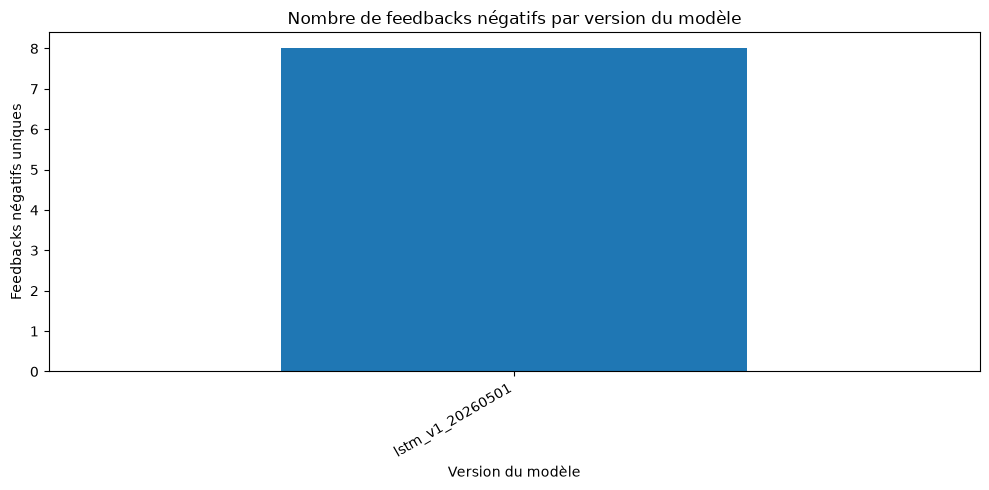

In [36]:
if df_negative.empty:
    model_stats = pd.DataFrame()
else:
    model_stats = (
        df_negative
        .groupby("model_version", dropna=False)
        .agg(
            feedbacks_negatifs=("log_id", "count"),
            sources=("source", "nunique"),
            hosts=("host", "nunique"),
            score_moyen=("score_ia", "mean"),
            ratio_moyen=("ratio_val", "mean"),
            anomalies=("statut", lambda values: int((values == "ANOMALIE").sum())),
            normaux=("statut", lambda values: int((values == "NORMAL").sum())),
        )
        .reset_index()
        .sort_values("feedbacks_negatifs", ascending=False)
    )

display(model_stats)

if not model_stats.empty:
    ax = model_stats.plot(
        kind="bar",
        x="model_version",
        y="feedbacks_negatifs",
        legend=False,
        figsize=(10, 5),
        title="Nombre de feedbacks négatifs par version du modèle",
    )
    ax.set_xlabel("Version du modèle")
    ax.set_ylabel("Feedbacks négatifs uniques")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


## 7. Répartition des retours négatifs par statut

,statut,feedbacks_negatifs
0,ANOMALIE,7
1,NORMAL,1


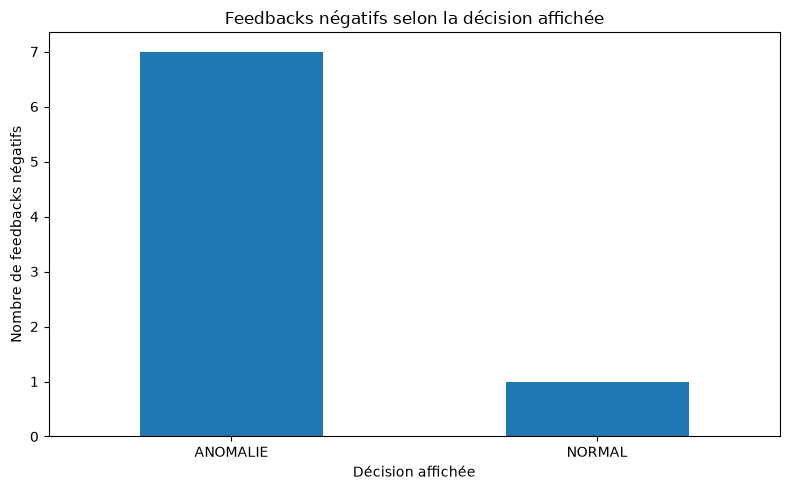

Interprétation prudente :
- négatif sur ANOMALIE : l'alerte, l'explication ou la recommandation a pu être jugée mauvaise ;
- négatif sur NORMAL : le comportement nominal, l'explication ou l'absence d'action a pu être contesté.
Ces cas doivent être vérifiés humainement avant d'être utilisés comme labels de réentraînement.


In [37]:
if not df_negative.empty:
    status_counts = (
        df_negative["statut"]
        .value_counts(dropna=False)
        .rename_axis("statut")
        .reset_index(name="feedbacks_negatifs")
    )

    display(status_counts)

    ax = status_counts.plot(
        kind="bar",
        x="statut",
        y="feedbacks_negatifs",
        legend=False,
        figsize=(8, 5),
        title="Feedbacks négatifs selon la décision affichée",
    )
    ax.set_xlabel("Décision affichée")
    ax.set_ylabel("Nombre de feedbacks négatifs")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

print(
    "Interprétation prudente :\n"
    "- négatif sur ANOMALIE : l'alerte, l'explication ou la recommandation a pu être jugée mauvaise ;\n"
    "- négatif sur NORMAL : le comportement nominal, l'explication ou l'absence d'action a pu être contesté.\n"
    "Ces cas doivent être vérifiés humainement avant d'être utilisés comme labels de réentraînement."
)


## 8. Sources, hosts et messages les plus concernés

In [38]:
def frequency_table(column: str, limit: int = 15) -> pd.DataFrame:
    if df_negative.empty or column not in df_negative.columns:
        return pd.DataFrame(columns=[column, "feedbacks_negatifs"])

    return (
        df_negative[column]
        .fillna("unknown")
        .astype(str)
        .value_counts()
        .head(limit)
        .rename_axis(column)
        .reset_index(name="feedbacks_negatifs")
    )


print("Sources les plus concernées")
display(frequency_table("source"))

print("Hosts les plus concernés")
display(frequency_table("host"))

print("Messages récurrents")
display(frequency_table("message"))


Sources les plus concernées


,source,feedbacks_negatifs
0,linux,8


Hosts les plus concernés


,host,feedbacks_negatifs
0,combo,8


Messages récurrents


,message,feedbacks_negatifs
0,session opened for user test by (uid=509),2
1,session opened for user news by (uid=0),2
2,cupsd shutdown succeeded,1
3,session closed for user news,1
4,cupsd startup succeeded,1
5,ALERT exited abnormally with [1],1


## 9. Inspection détaillée des cas négatifs

In [39]:
columns_to_show = [
    "timestamp_normalized",
    "model_version",
    "source",
    "host",
    "message",
    "score_ia",
    "ratio_val",
    "statut",
    "rag_analysis",
    "rag_recommendation",
]

available_columns = [
    column for column in columns_to_show
    if column in df_negative.columns
]

negative_cases = df_negative[available_columns].copy()

display(negative_cases)


,timestamp_normalized,model_version,source,host,message,score_ia,ratio_val,statut,rag_analysis,rag_recommendation
0,2026-06-15 21:47:01+00:00,lstm_v1_20260501,linux,combo,session opened for user test by (uid=509),2.35,1.80,ANOMALIE,"Le message indique qu’une session a été ouverte pour l’utilisateur « test » avec l’UID 509 sur le hôte « combo ». Le score IA de 2,35 suggère une détection d’anomalie, et le ra...","1. Vérifier les logs d’authentification autour de ce timestamp pour confirmer qu’il s’agit d’une connexion légitime. 2. Si aucune activité suspecte n’est trouvée, ajuster le se..."
1,2026-06-15 21:46:49+00:00,lstm_v1_20260501,linux,combo,session opened for user test by (uid=509),2.02,1.55,ANOMALIE,"Le message indique qu’une session a été ouverte pour l’utilisateur « test » (uid 509) sur l’hôte « combo ». Le score IA de 2,02 et le ratio 1,55× dépassent le seuil de 1,3, ce ...",1. Enregistrer l’événement dans le registre d’anomalies. 2. Mettre en place une alerte pour toute connexion supplémentaire de l’UID 509. 3. Si d’autres connexions suspectes app...
2,2026-06-15 21:46:25+00:00,lstm_v1_20260501,linux,combo,cupsd shutdown succeeded,1.72,1.32,ANOMALIE,Le modèle classe ce log comme anomalie car son ratio (1.32x) dépasse le seuil configuré (1.3x). Le service linux sur combo présente un comportement inhabituel.,"Inspecter le service, corréler avec les logs voisins, vérifier les accès récents et redémarrer le pod si nécessaire."
3,2026-06-15 20:36:53+00:00,lstm_v1_20260501,linux,combo,session opened for user news by (uid=0),2.02,1.54,ANOMALIE,Le modèle classe ce log comme anomalie car son ratio (1.54x) dépasse le seuil configuré (1.3x). Le service linux sur combo présente un comportement inhabituel.,"Inspecter le service, corréler avec les logs voisins, vérifier les accès récents et redémarrer le pod si nécessaire."
4,2026-06-15 19:37:54+00:00,lstm_v1_20260501,linux,combo,session closed for user news,1.68,1.29,NORMAL,"Le log indique que la session de l’utilisateur « news » a été fermée sur le serveur « combo ». Le score IA de 1,68 et le ratio de 1,29× se situent juste en dessous du seuil de ...","Consulter les journaux d’authentification (ex. /var/log/auth.log) pour confirmer la cause exacte de la fermeture. Si le timeout est confirmé, envisager d’ajuster la valeur de T..."
5,2026-06-15 19:24:56+00:00,lstm_v1_20260501,linux,combo,cupsd startup succeeded,2.07,1.58,ANOMALIE,"Le message indique que le service cupsd a démarré correctement sur l’hôte combo. Le score IA de 2,07 et le ratio de 1,58x dépassent le seuil de 1,3, déclenchant une alerte d’an...","Continuer de surveiller le service cupsd sur les prochaines 24 heures. Enregistrer les métriques de ressources (CPU, mémoire, disque) pour vérifier qu’elles restent dans les li..."
6,2026-06-15 17:44:57+00:00,lstm_v1_20260501,linux,combo,ALERT exited abnormally with [1],1.98,1.51,ANOMALIE,Le modèle classe ce log comme anomalie car son ratio (1.51x) dépasse le seuil configuré (1.3x). Le service linux sur combo présente un comportement inhabituel.,"Inspecter le service, corréler avec les logs voisins, vérifier les accès récents et redémarrer le pod si nécessaire."
7,2026-06-15 17:44:32+00:00,lstm_v1_20260501,linux,combo,session opened for user news by (uid=0),2.02,1.54,ANOMALIE,"Le log indique qu’une session a été ouverte pour l’utilisateur « news » avec un UID 0, signifiant un accès root. Le score IA de 2,02 et le ratio de 1,54x dépassent le seuil de ...",Consultez le fichier /etc/passwd et les droits sudo pour le compte « news ». Analysez les logs d’authentification récents pour confirmer si cette connexion était prévue. Si auc...


## 10. Évolution temporelle des feedbacks négatifs

c:\Users\eyakh\Downloads\logguardian\.venv\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1613: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


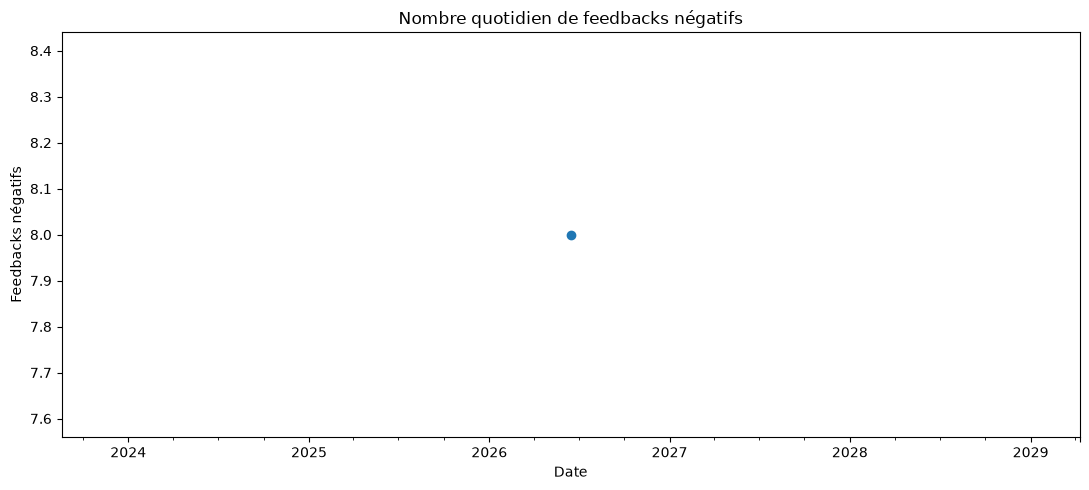

In [40]:
if not df_negative.empty:
    time_df = (
        df_negative
        .dropna(subset=["timestamp_normalized"])
        .set_index("timestamp_normalized")
        .sort_index()
    )

    if not time_df.empty:
        daily_counts = time_df.resample("D").size()

        ax = daily_counts.plot(
            figsize=(11, 5),
            marker="o",
            title="Nombre quotidien de feedbacks négatifs",
        )
        ax.set_xlabel("Date")
        ax.set_ylabel("Feedbacks négatifs")
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune date valide pour construire la série temporelle.")
else:
    print("Aucun feedback négatif.")


## 11. Export des cas à revoir

In [41]:
EXPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

negative_cases.to_csv(
    EXPORT_PATH,
    index=False,
    encoding="utf-8-sig",
)

print(f"Export créé : {EXPORT_PATH}")


Export créé : C:\Users\eyakh\Downloads\logguardian\feedback\negative_feedback_analysis.csv


## 12. Conclusion automatique

In [42]:
print("=" * 70)
print("RAPPORT QUALITATIF DES FEEDBACKS NÉGATIFS — LOGGUARDIAN")
print("=" * 70)

print(f"Cas négatifs uniques : {len(df_negative)}")

if df_negative.empty:
    print("Aucun cas négatif à analyser.")
else:
    top_model = df_negative["model_version"].value_counts().idxmax()
    top_source = df_negative["source"].value_counts().idxmax()
    anomaly_count = int((df_negative["statut"] == "ANOMALIE").sum())
    normal_count = int((df_negative["statut"] == "NORMAL").sum())

    print(f"Version la plus représentée : {top_model}")
    print(f"Source la plus concernée     : {top_source}")
    print(f"Cas classés ANOMALIE         : {anomaly_count}")
    print(f"Cas classés NORMAL           : {normal_count}")
    print()
    print("Plan d'action recommandé :")
    print("1. Relire manuellement les cas exportés dans negative_feedback_analysis.csv.")
    print("2. Distinguer les mauvaises explications RAG des mauvaises classifications.")
    print("3. Ne convertir en labels d'entraînement que les cas validés par un opérateur.")
    print("4. Créer un fichier de vérité terrain séparé avant de calculer précision, rappel et F1.")


RAPPORT QUALITATIF DES FEEDBACKS NÉGATIFS — LOGGUARDIAN
Cas négatifs uniques : 8
Version la plus représentée : lstm_v1_20260501
Source la plus concernée     : linux
Cas classés ANOMALIE         : 7
Cas classés NORMAL           : 1

Plan d'action recommandé :
1. Relire manuellement les cas exportés dans negative_feedback_analysis.csv.
2. Distinguer les mauvaises explications RAG des mauvaises classifications.
3. Ne convertir en labels d'entraînement que les cas validés par un opérateur.
4. Créer un fichier de vérité terrain séparé avant de calculer précision, rappel et F1.
